In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Resume.csv')

In [5]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [8]:
df.shape

(2484, 4)

In [18]:
df=df.drop(['ID','Resume_html'],axis=1)

In [19]:
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [20]:
df.shape

(2484, 2)

In [21]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

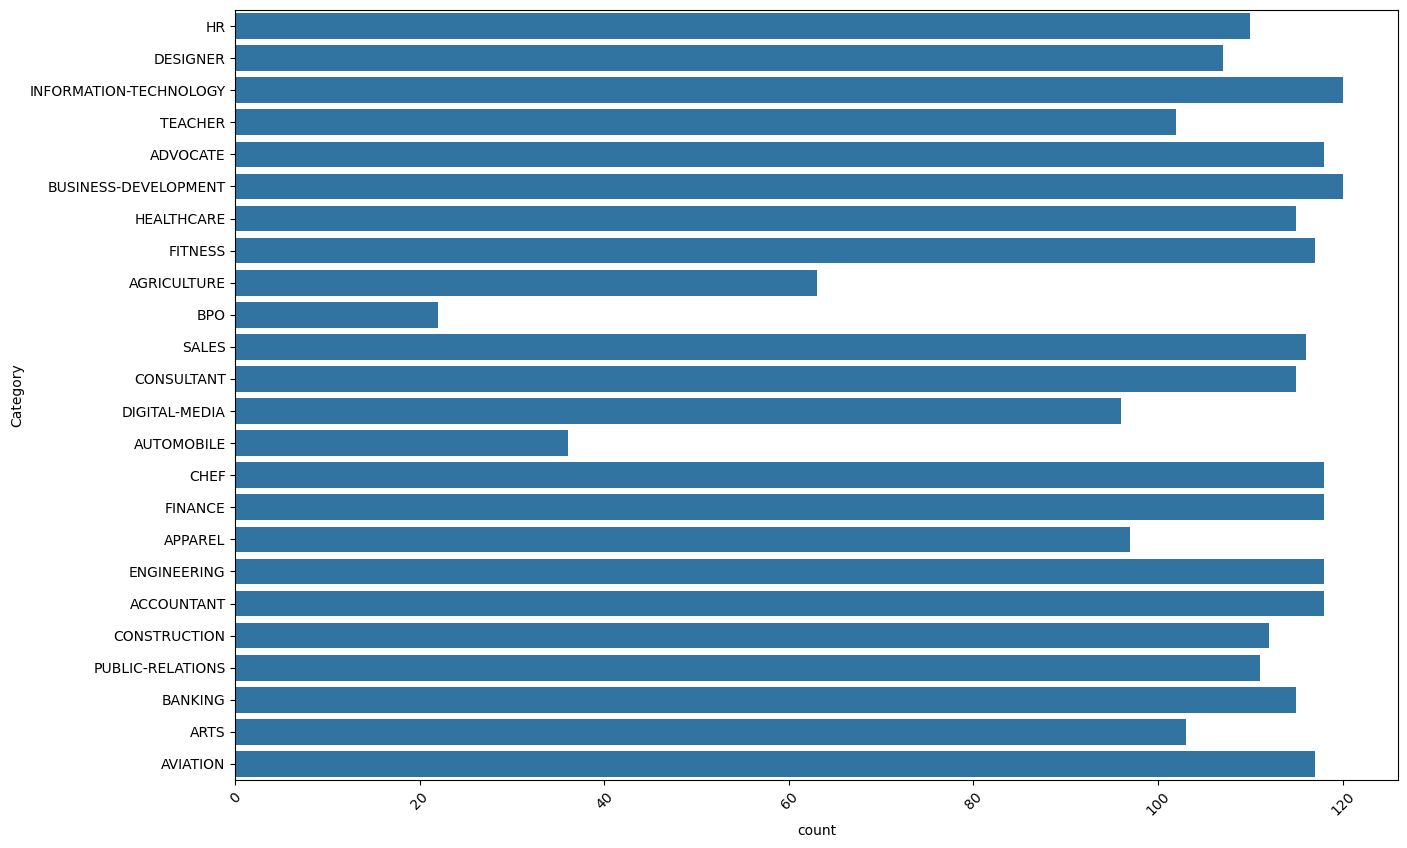

In [28]:
plt.figure(figsize=(15,10))
sns.countplot(df['Category'])
plt.xticks(rotation=45)
plt.show()

In [34]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

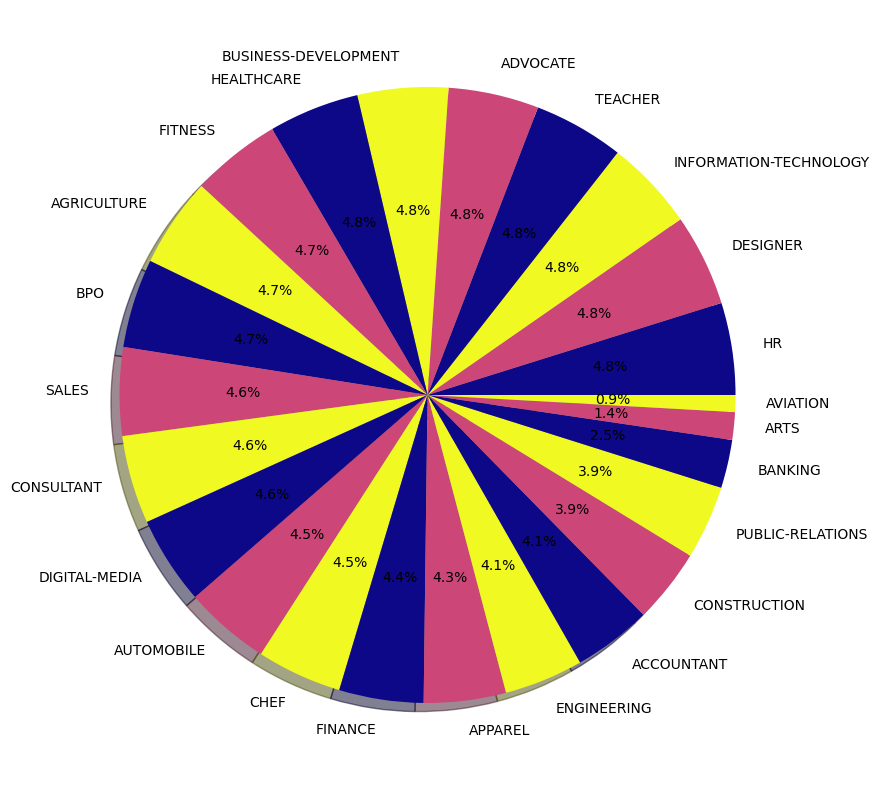

In [43]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts, labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

In [61]:
df['Category'][0]

'HR'

In [62]:
df['Resume_str'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [ ]:
#CLEANING DATA

In [5]:
import re
def cleanResume(txt):
    cleanTxt = re.sub('http\S+\s',' ',txt)
    cleanTxt = re.sub('@\S+',' ',cleanTxt)
    cleanTxt = re.sub('#\S+',' ',cleanTxt)
    cleanTxt = re.sub('RT|cc',' ',cleanTxt)
    cleanTxt = re.sub('[%s]' % re.escape("""!"#$&'()*+,-./;:<>=?@[\]^_`{|}~"""),' ',cleanTxt)
    cleanTxt = re.sub(r'[^\x00-\x7f]',' ',cleanTxt)
    cleanTxt = re.sub('\s+',' ',cleanTxt)
    return cleanTxt

In [59]:
df['Resume']=df['Resume_str'].apply(lambda x: cleanResume(x))

In [111]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\boini\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\boini\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\boini\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\boini\AppData\Roaming\nltk_data...


True

In [112]:
df['Resume'] = df['Resume'].str.lower()

In [113]:
df['Resume']

0        hr administrator marketing associate hr admin...
1        hr specialist us hr operations summary versat...
2        hr director summary over 20 years experience ...
3        hr specialist summary dedicated driven and dy...
4        hr manager skill highlights hr skills hr depa...
                              ...                        
2479     rank sgt e 5 non commissioned officer in char...
2480     government relations communications and organ...
2481     geek squad agent professional profile it supp...
2482     program director office manager summary highl...
2483     storekeeper ii professional summary the purpo...
Name: Resume, Length: 2484, dtype: object

In [115]:
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['Tokens'] = df['Resume'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\boini\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [116]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Tokens'] = df['Tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [117]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Tokens'] = df['Tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [118]:
df['Processed_Resume'] = df['Tokens'].apply(lambda words: " ".join(words))

In [63]:
#WORDS INTO CATEGORICAL VALUES

In [66]:
df = df.drop(['Resume_str'],axis=1)

In [68]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [69]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [71]:
df.Category.unique()

array([19, 13, 20, 23,  1,  9, 18, 17,  2,  8, 22, 12, 14,  5, 10, 16,  3,
       15,  0, 11, 21,  7,  4,  6])

In [74]:
df.head()

,Category,Resume
0,19,HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMIN...
1,19,HR SPECIALIST US HR OPERATIONS Summary Versat...
2,19,HR DIRECTOR Summary Over 20 years experience ...
3,19,HR SPECIALIST Summary Dedicated Driven and Dy...
4,19,HR MANAGER Skill Highlights HR SKILLS HR Depa...


In [72]:
# ['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
#        'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
#        'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
#        'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
#        'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']

In [73]:
#VECTORIZATION

In [119]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Processed_Resume'])
X = tfidf.transform(df['Processed_Resume'])
y = df['Category']

In [77]:
#SPLITTING DATA 

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2 ,random_state = 42)

In [122]:
X_train.shape

(1987, 35976)

In [123]:
X_test.shape

(497, 35976)

In [82]:
#TRAIN THE MODEL

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lg =LogisticRegression()
# clf = KNeighborsClassifier()
lg.fit(X_train, y_train)
ypred = lg.predict(X_test)
print(accuracy_score(y_test,ypred))

0.6237424547283702


In [ ]:
#PREDICTION SYSTEM

In [126]:
import pickle
pickle.dump(tfidf, open('tfidf.pkl','wb'))
pickle.dump(lg, open('lg.pkl','wb'))

In [2]:
#MAPPING

values = [19, 13, 20, 23,  1,  9, 18, 17,  2,  8, 22, 12, 14,  5, 10, 16,  3,
       15,  0, 11, 21,  7,  4,  6]

category = ['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']

category_mapping = {}

for i in range(len(values)):
    category_mapping.update({values[i]: category[i]})

print(category_mapping)    

{19: 'HR', 13: 'DESIGNER', 20: 'INFORMATION-TECHNOLOGY', 23: 'TEACHER', 1: 'ADVOCATE', 9: 'BUSINESS-DEVELOPMENT', 18: 'HEALTHCARE', 17: 'FITNESS', 2: 'AGRICULTURE', 8: 'BPO', 22: 'SALES', 12: 'CONSULTANT', 14: 'DIGITAL-MEDIA', 5: 'AUTOMOBILE', 10: 'CHEF', 16: 'FINANCE', 3: 'APPAREL', 15: 'ENGINEERING', 0: 'ACCOUNTANT', 11: 'CONSTRUCTION', 21: 'PUBLIC-RELATIONS', 7: 'BANKING', 4: 'ARTS', 6: 'AVIATION'}


In [3]:
myresume="""RAHUL KUMAR

Advocate

Bar Council Registration No.: MH/XXXX/2023

Email: rahul.kumar@email.com | Phone: +91 98XXXXXXXX

Mumbai, Maharashtra

 

PROFESSIONAL SUMMARY

Recent law graduate with strong academic credentials and practical experience through internships at leading law firms. Demonstrated expertise in legal research, document drafting, and client consultation. Seeking an associate position to leverage my knowledge of constitutional and corporate law.

 

EDUCATION

- LL.B., Government Law College, Mumbai (2020-2023)

  - First Class with Distinction (85%)

  - Secretary, Moot Court Society

  - Winner, National Constitutional Law Competition 2022

 

INTERNSHIPS

- Junior Associate Intern, Shah & Associates (May-July 2023)

  - Assisted in research for 15+ corporate law cases

  - Drafted legal notices and agreements

  - Participated in client consultations

 

SKILLS

- Legal Research: Manupatra, SCC Online, IndianKanoon

- Documentation: Legal drafting, case briefs, opinions

- Languages: English, Hindi, Marathi (Written and Verbal)

- Technical: MS Office Suite, Legal Software"""

In [9]:
import pickle
lg = pickle.load(open('lg.pkl','rb'))
tfidf = pickle.load(open('tfidf.pkl','rb'))
cleaned_resume = cleanResume(myresume)

input_features = tfidf.transform([cleaned_resume])

prediction_id = lg.predict(input_features)[0]

category_name = category_mapping.get(prediction_id,"unknown")

print("predicted Category:",category_name)
print(prediction_id)

predicted Category: ADVOCATE
1
